# Libraries

In [1]:
'''
!pip uninstall -y scipy gensim nltk
!pip install scipy==1.11.4 gensim==4.3.2 nltk==3.8.1

!pip install numpy==1.26.4 --force-reinstall
!pip install pandas==2.1.3 --force-reinstall
!pip install matplotlib==3.8.2 --force-reinstall


'''

'\n!pip uninstall -y scipy gensim nltk\n!pip install scipy==1.11.4 gensim==4.3.2 nltk==3.8.1\n\n!pip install numpy==1.26.4 --force-reinstall\n!pip install pandas==2.1.3 --force-reinstall\n!pip install matplotlib==3.8.2 --force-reinstall\n\n\n'

In [2]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV


import nltk
nltk.download('punkt')  # Tokenizer support

from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.tokenize import RegexpTokenizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import seaborn as sns


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


# Dataset

In [3]:

df = pd.read_csv(r'/content/converted_judgments (1).csv')
df.rename(columns={'Facts': 'facts'}, inplace=True)
df.drop(columns=['ID'], inplace=True)
df.reset_index(inplace=True)

print(f'There are {len(df)} cases.')

There are 3303 cases.


In [4]:
df

,index,name,href,first_party,second_party,winning_party,winner_index,facts
0,0,Jane Roe v. Henry Wade,https://api.oyez.org/cases/1971/70-18,Jane Roe,Henry Wade,NaN,NaN,"<p>In 1970, Jane Roe (a fictional name used in..."
1,1,"Peter Stanley, Sr. v. Illinois",https://api.oyez.org/cases/1971/70-5014,"Peter Stanley, Sr.",Illinois,NaN,NaN,<p>Joan Stanley had three children with Peter ...
2,2,John Giglio v. United States,https://api.oyez.org/cases/1971/70-29,John Giglio,United States,NaN,NaN,<p>John Giglio was convicted of passing forged...
3,3,Sally Reed v. Cecil Reed,https://api.oyez.org/cases/1971/70-4,Sally Reed,Cecil Reed,NaN,NaN,"<p>The Idaho Probate Code specified that ""male..."
4,4,Marvin Miller v. California,https://api.oyez.org/cases/1971/70-73,Marvin Miller,California,NaN,NaN,"<p>Miller, after conducting a mass mailing cam..."
...,...,...,...,...,...,...,...,...
3298,3298,United States v. Refugio Palomar-Santiago,https://api.oyez.org/cases/2020/20-437,United States,Refugio Palomar-Santiago,NaN,NaN,"<p>Refugio Palomar-Santiago, a Mexican nationa..."
3299,3299,Tarahrick Terry v. United States,https://api.oyez.org/cases/2020/20-5904,Tarahrick Terry,United States,NaN,NaN,<p>Tarahrick Terry pleaded guilty to one count...
3300,3300,United States v. Joshua James Cooley,https://api.oyez.org/cases/2020/19-1414,United States,Joshua James Cooley,NaN,NaN,<p>Joshua James Cooley was parked in his picku...
3301,3301,Florida v. Georgia,https://api.oyez.org/cases/2020/142-orig,Florida,Georgia,NaN,NaN,<p>This is an ongoing case of original jurisdi...


In [5]:
df.head(5)

,index,name,href,first_party,second_party,winning_party,winner_index,facts
0,0,Jane Roe v. Henry Wade,https://api.oyez.org/cases/1971/70-18,Jane Roe,Henry Wade,NaN,NaN,"<p>In 1970, Jane Roe (a fictional name used in..."
1,1,"Peter Stanley, Sr. v. Illinois",https://api.oyez.org/cases/1971/70-5014,"Peter Stanley, Sr.",Illinois,NaN,NaN,<p>Joan Stanley had three children with Peter ...
2,2,John Giglio v. United States,https://api.oyez.org/cases/1971/70-29,John Giglio,United States,NaN,NaN,<p>John Giglio was convicted of passing forged...
3,3,Sally Reed v. Cecil Reed,https://api.oyez.org/cases/1971/70-4,Sally Reed,Cecil Reed,NaN,NaN,"<p>The Idaho Probate Code specified that ""male..."
4,4,Marvin Miller v. California,https://api.oyez.org/cases/1971/70-73,Marvin Miller,California,NaN,NaN,"<p>Miller, after conducting a mass mailing cam..."


# Data Preprocessing

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3303 entries, 0 to 3302
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          3303 non-null   int64  
 1   name           3303 non-null   object 
 2   href           3303 non-null   object 
 3   first_party    3302 non-null   object 
 4   second_party   3302 non-null   object 
 5   winning_party  29 non-null     object 
 6   winner_index   29 non-null     float64
 7   facts          3303 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 206.6+ KB


In [7]:
print(f'There are {len(df)} cases.')


There are 3303 cases.


In [8]:
df['facts'].apply(lambda x: len(str(x).split())).describe()

,facts
count,3303.000000
mean,46.545565
std,4.105767
min,2.000000
25%,44.000000
50%,47.000000
75%,49.000000
max,61.000000


In [9]:

text_vectorization = keras.layers.TextVectorization(
    max_tokens=1000,
    output_mode="multi_hot",
)
text_vectorization.adapt(df['facts'])
vectorized_facts = text_vectorization(df['facts'])


lengths = [len(x) for x in vectorized_facts]

In [10]:
name_pet = []
name_rep = []

for i in range(df.shape[0]):
    fact = str(df["facts"][i])
    petitioner = str(df["first_party"][i]) if pd.notna(df["first_party"][i]) else ""
    respondent = str(df["second_party"][i]) if pd.notna(df["second_party"][i]) else ""

    p = False
    r = False

    for _ in petitioner.split():
        if _ in fact:
            p = True
            break
    if not p:
        name_pet.append(i)

    for _ in respondent.split():
        if _ in fact:
            r = True
            break
    if not r:
        name_rep.append(i)


In [11]:
print("Total rows:", df.shape[0])


Total rows: 3303


In [12]:
perc_miss_pet = len(name_pet) / len(df) * 100
print('{:.2f}% of facts don\'t contain the first party name'.format(perc_miss_pet))

perc_miss_rep = len(name_rep) / len(df) * 100
print('{:.2f}% of facts don\'t contain the second party name'.format(perc_miss_rep))

perc_miss_both = len(set(set(name_pet) & set(name_rep))) / len(df) * 100
print('{:.2f}% of facts don\'t contain both first party the second party names'.format(perc_miss_both))

28.97% of facts don't contain the first party name
32.64% of facts don't contain the second party name
8.69% of facts don't contain both first party the second party names


In [13]:
# Combining first and second party with facts
df['facts'] = df['first_party']+' '+df['second_party']+' '+df['facts']
df['facts'][50]

"Jule M. Sugarman, Administrator, New York City Human Resources Administration et al. Patrick McL. Dougall et al. <p>Patrick Dougall was a federally registered resident alien. He was employed by a nonprofit organization that was absorbed into the Manpower Career and Development Agency (MCDA) of New York City's Human Resources Administration. He was ineligible for employment by the city under Section 53 of the N"

winner_index
0.0    18
1.0    11
Name: count, dtype: int64


<Axes: ylabel='Type'>

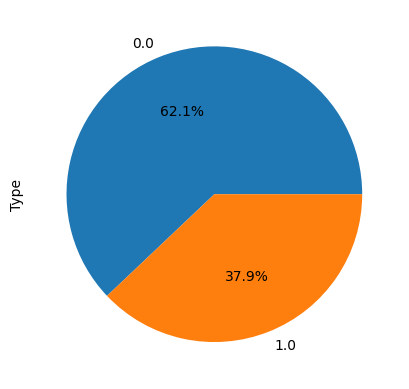

In [14]:
print(df["winner_index"].value_counts())

df.groupby('winner_index').size().plot(kind='pie',
                                       y = "winner_index",
                                       label = "Type",
                                       autopct='%1.1f%%')

In [15]:
# Drop rows with NaN in 'winner_index' or 'facts' before splitting
df = df.dropna(subset=['winner_index', 'facts'])

# Spliting 70-30 for training and testing data
X_train, X_test, \
y_train, y_test = train_test_split(
    df[['winner_index', 'facts']],
    df['winner_index'],
    test_size=0.3,
    stratify=df['winner_index'],
    random_state=865
)


In [16]:
petitioner = X_train[X_train["winner_index"] == 0]
respondent = X_train[X_train["winner_index"] == 1]


In [17]:
#Upsample data
from sklearn.utils import resample
upsample_respondent = resample(respondent,
             replace=True,
             n_samples=len(petitioner),
             random_state=865)

winner_index
1.0    12
0.0    12
Name: count, dtype: int64


<Axes: ylabel='Type'>

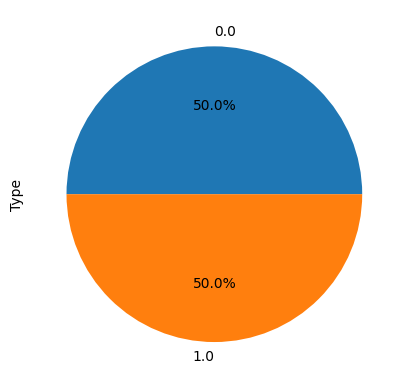

In [18]:
upsample_train = pd.concat([upsample_respondent, petitioner])

print(upsample_train["winner_index"].value_counts())

upsample_train.groupby('winner_index').size().plot(kind='pie',
                                       y = "winner_index",
                                       label = "Type",
                                       autopct='%1.1f%%')

In [19]:
#shuffling
shuffled_indices= np.arange(upsample_train.shape[0])
np.random.shuffle(shuffled_indices)

In [20]:
shuffled_train = upsample_train.iloc[shuffled_indices,:]
X_train= shuffled_train['facts']
y_train = shuffled_train['winner_index']

In [21]:
X_test = X_test['facts']

# Algorithms Implementation

# 1- Neural Network:

In [22]:
def nltk_tokenizer(_wd):
    return RegexpTokenizer(r'\w+').tokenize(_wd.lower())

In [23]:
# turn X data into pandas dataframe to use custom defined function on a column in dataframe
X_train_frame = X_train.to_frame()
X_test_frame = X_test.to_frame()

# tokenize facts
X_train_frame["tokenized_facts"] = X_train_frame["facts"].apply(nltk_tokenizer)
X_test_frame["tokenized_facts"] = X_test_frame["facts"].apply(nltk_tokenizer)

# make taggeddocument, which is required format to use Doc2vec
tokens_train = X_train_frame["tokenized_facts"].to_list()
docs_train = [TaggedDocument(t, [str(i)]) for i, t in enumerate(tokens_train)]
tokens_test = X_test_frame["tokenized_facts"].to_list()
docs_test = [TaggedDocument(t, [str(i)]) for i, t in enumerate(tokens_test)]

In [24]:
# innitiate doc2vec model and train it on train data
doc2vec_model = Doc2Vec(vector_size=50, min_count=2, epochs=40, dm=1, seed=865, window=5)
doc2vec_model.build_vocab(docs_train)
doc2vec_model.train(docs_train, total_examples = doc2vec_model.corpus_count, epochs = doc2vec_model.epochs)

In [25]:
# vectorize train and test data using doc2vec model
X_train_dvs = [doc2vec_model.infer_vector(doc) for doc in tokens_train]
X_train_dvs = pd.DataFrame(X_train_dvs, index = X_train.index)

X_test_dvs = [doc2vec_model.infer_vector(doc) for doc in tokens_test]
X_test_dvs = pd.DataFrame(X_test_dvs, index = X_test.index)

In [26]:
# define Dense layer model
def simple_model():
    model =  keras.Sequential([
        layers.Dropout(0.3),
        layers.BatchNormalization(),
        layers.Dense(200, activation="relu", kernel_regularizer="l1"),
        layers.Dropout(0.3),
        layers.BatchNormalization(),
        layers.Dense(100, activation="relu", kernel_regularizer="l1"),
        layers.Dropout(0.4),
        layers.BatchNormalization(),
        layers.Dense(50, activation="relu"),
        layers.Dropout(0.4),
        layers.BatchNormalization(),
        layers.Dense(20, activation="relu"),
        layers.Dropout(0.4),
        layers.BatchNormalization(),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    return model

In [27]:
# training and cross validattion
k = 4
num_validation_samples = len(X_train_dvs) // k
num_epochs = 20
batch_sizes = 50
all_loss_histories = []
all_val_loss_histories = []
all_acc_histories = []
all_val_acc_histories = []

# For each validation fold, we will train a full set of epochs, and store the history.
for fold in range(k):
    validation_data = X_train_dvs[num_validation_samples * fold:
                           num_validation_samples * (fold + 1)]
    validation_targets = y_train[num_validation_samples * fold:
                           num_validation_samples * (fold + 1)]
    training_data = np.concatenate([
        X_train_dvs[:num_validation_samples * fold],
        X_train_dvs[num_validation_samples * (fold + 1):]])
    training_targets = np.concatenate([
        y_train[:num_validation_samples * fold],
        y_train[num_validation_samples * (fold + 1):]])

    model1 = simple_model()

    history1 = model1.fit(training_data, training_targets,
                    validation_data = (validation_data,validation_targets),
                    epochs=num_epochs, batch_size=batch_sizes)

    val_loss_history1 = history1.history['val_loss']
    val_acc_history1 = history1.history['val_accuracy']
    loss_history1 = history1.history['loss']
    acc_history1 = history1.history['accuracy']
    all_val_loss_histories.append(val_loss_history1)
    all_loss_histories.append(loss_history1)
    all_val_acc_histories.append(val_acc_history1)
    all_acc_histories.append(acc_history1)

average_loss_history = [np.mean([x[i] for x in all_loss_histories]) for i in range(num_epochs)]
average_val_loss_history = [np.mean([x[i] for x in all_val_loss_histories]) for i in range(num_epochs)]
average_acc_history = [np.mean([x[i] for x in all_acc_histories]) for i in range(num_epochs)]
average_val_acc_history = [np.mean([x[i] for x in all_val_acc_histories]) for i in range(num_epochs)]

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.3889 - loss: 23.2112 - val_accuracy: 0.3333 - val_loss: 22.7156
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6667 - loss: 22.7453 - val_accuracy: 0.3333 - val_loss: 22.6120
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4444 - loss: 22.7836 - val_accuracy: 0.3333 - val_loss: 22.5159
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5000 - loss: 22.6706 - val_accuracy: 0.3333 - val_loss: 22.4196
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.6111 - loss: 22.5333 - val_accuracy: 0.3333 - val_loss: 22.3223
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4444 - loss: 22.4270 - val_accuracy: 0.3333 - val_loss: 22.2243
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4444 - loss: 22.4312 - val_accuracy: 0.3333 - val_loss: 22.1268
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5000 - loss: 22.2410 - val_accuracy: 0.3333

In [28]:
np.mean(average_val_acc_history)

0.4020833386108279

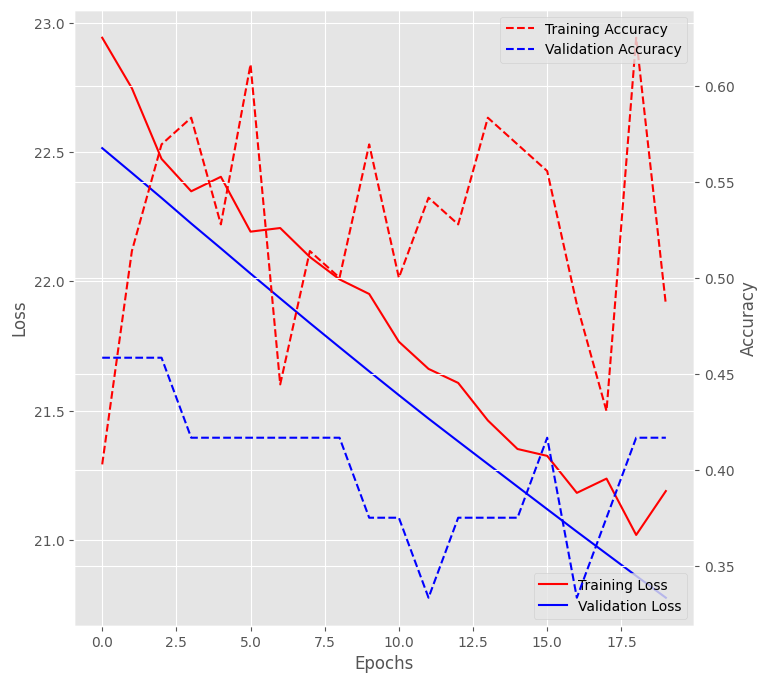

In [29]:
# plot loss and accuracy on train, validation data

plt.style.use('ggplot')

fig, ax=plt.subplots(figsize=(8,8))
ax.plot(average_loss_history,c='r', label="Training Loss")
ax.plot(average_val_loss_history,c='b', label="Validation Loss")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.legend(['Training Loss','Validation Loss'], loc="lower right")

ax2=ax.twinx()
ax2.plot(average_acc_history,c="r",linestyle="dashed", label="Training Accuracy")
ax2.plot(average_val_acc_history,c='b',linestyle="dashed", label="Validation Accuracy")
ax2.set_ylabel("Accuracy")
ax2.legend(["Training Accuracy", "Validation Accuracy"], loc="upper right")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


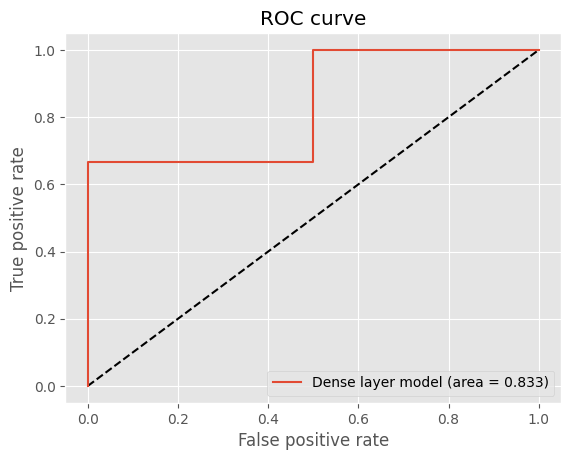

In [30]:
from sklearn.metrics import roc_curve
y_pred1 = model1.predict(X_test_dvs).ravel()
fpr_1, tpr_1, thresholds_1 = roc_curve(y_test, y_pred1)

from sklearn.metrics import auc
auc_1 = auc(fpr_1, tpr_1)

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_1, tpr_1, label='Dense layer model (area = {:.3f})'.format(auc_1))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

In [31]:
# model evaluation using test data
loss_metrics = model1.evaluate(X_test_dvs,y_test,verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6667 - loss: 20.4124


# 2-  Convolutional Neural Network

In [32]:
# Before building CNN model, vectorize facts data
text_vectorization = keras.layers.TextVectorization(
    max_tokens=2000,
    output_mode="int",
    output_sequence_length = 500
)

text_vectorization.adapt(X_train)

X_train_processed = text_vectorization(X_train)
X_test_processed = text_vectorization(X_test)

In [33]:
# Build CNN model
def cnn_model():
    input = keras.Input(shape=(500,))
    x = layers.Embedding(input_dim=2000,output_dim=8,input_length=500, mask_zero=True)(input)
    x = layers.Conv1D(filters=40,kernel_size=10,activation="relu")(x)
    x = layers.MaxPool1D(pool_size=2,strides=2)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(10,activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=input,outputs=output)

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])
    return model

In [34]:
# train and cross validate the model
k = 4
num_validation_samples = len(X_train_dvs) // k
num_epochs = 20
batch_sizes = 50
all_loss_histories = []
all_val_loss_histories = []
all_acc_histories = []
all_val_acc_histories = []

# For each validation fold, we will train a full set of epochs, and store the history.
for fold in range(k):
    validation_data = X_train_processed[num_validation_samples * fold:
                           num_validation_samples * (fold + 1)]
    validation_targets = y_train[num_validation_samples * fold:
                           num_validation_samples * (fold + 1)]
    training_data = np.concatenate([
        X_train_processed[:num_validation_samples * fold],
        X_train_processed[num_validation_samples * (fold + 1):]])
    training_targets = np.concatenate([
        y_train[:num_validation_samples * fold],
        y_train[num_validation_samples * (fold + 1):]])

    model2 = cnn_model()

    history2 = model2.fit(training_data, training_targets,
                    validation_data = (validation_data,validation_targets),
                    epochs=num_epochs, batch_size=batch_sizes)

    val_loss_history2 = history2.history['val_loss']
    val_acc_history2 = history2.history['val_accuracy']
    loss_history2 = history2.history['loss']
    acc_history2 = history2.history['accuracy']
    all_val_loss_histories.append(val_loss_history2)
    all_loss_histories.append(loss_history2)
    all_val_acc_histories.append(val_acc_history2)
    all_acc_histories.append(acc_history2)

average_loss_history = [np.mean([x[i] for x in all_loss_histories]) for i in range(num_epochs)]
average_val_loss_history = [np.mean([x[i] for x in all_val_loss_histories]) for i in range(num_epochs)]
average_acc_history = [np.mean([x[i] for x in all_acc_histories]) for i in range(num_epochs)]
average_val_acc_history = [np.mean([x[i] for x in all_val_acc_histories]) for i in range(num_epochs)]

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4444 - loss: 0.6935

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4444 - loss: 0.6935 - val_accuracy: 0.6667 - val_loss: 0.6906
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.5556 - loss: 0.6931 - val_accuracy: 0.6667 - val_loss: 0.6900
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.5000 - loss: 0.6948 - val_accuracy: 0.6667 - val_loss: 0.6900
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.4444 - loss: 0.6956 - val_accuracy: 0.6667 - val_loss: 0.6910
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.2222 - loss: 0.6959 - val_accuracy: 0.6667 - val_loss: 0.6923
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.4444 - loss: 0.6942 - val_accuracy: 0.6667 - val_loss: 0.6930
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6111 - loss: 0.6930 - val_accuracy: 0.6667 - val_loss: 0.6931
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.3333 - loss: 0.6933 - val_accuracy: 0.3333 - val_loss: 0.6934
Epoch 

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.5000 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5556 - loss: 0.6920 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3889 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.6111 - loss: 0.6921 - val_accuracy: 0.6667 - val_loss: 0.6930
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.4444 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3889 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5556 - loss: 0.6922 - val_accuracy: 0.5000 - val_loss: 0.6929
Epo

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d_3' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3889 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d_3' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.5556 - loss: 0.6924 - val_accuracy: 0.6667 - val_loss: 0.6931
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6111 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.5556 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.7778 - loss: 0.6897 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.4444 - loss: 0.6952 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.5000 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.6111 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6111 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6929
Epo

In [35]:
np.mean(average_val_acc_history)

0.4625000063329935

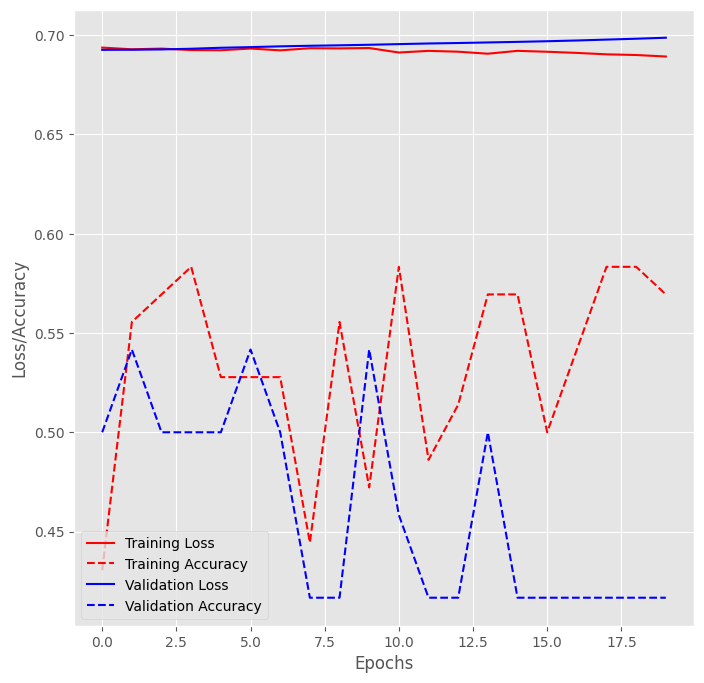

In [36]:
plt.style.use('ggplot')
plt.figure(figsize=(8,8))
plt.plot(average_loss_history,c='r')
plt.plot(average_acc_history,c="r",linestyle="dashed")
plt.plot(average_val_loss_history,c='b')
plt.plot(average_val_acc_history,c='b',linestyle="dashed")
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.legend(['Training Loss','Training Accuracy','Validation Loss','Validation Accuracy'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d_3' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


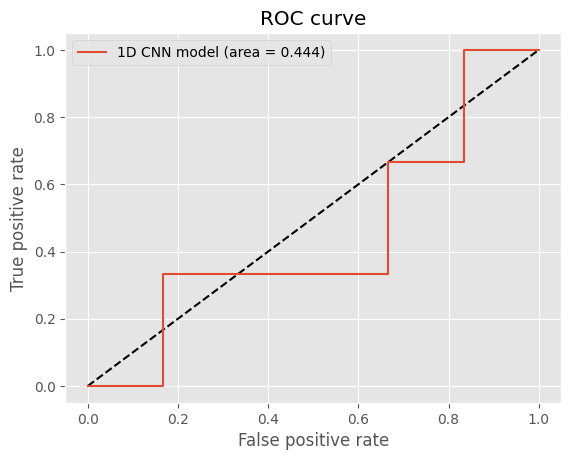

In [37]:
from sklearn.metrics import roc_curve
y_pred2 = model2.predict(X_test_processed).ravel()
fpr_2, tpr_2, thresholds_2 = roc_curve(y_test, y_pred2)

from sklearn.metrics import auc
auc_2 = auc(fpr_2, tpr_2)

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_2, tpr_2, label='1D CNN model (area = {:.3f})'.format(auc_2))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

In [38]:
loss_metrics = model2.evaluate(X_test_processed,y_test,verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6667 - loss: 0.6908


# 3- Bi-grams + TD-IDF

In [39]:
text_vectorization_bi_tfidf = keras.layers.TextVectorization(
    ngrams=2,
    max_tokens=20000,
    output_mode = "tf_idf",
)

In [40]:
text_vectorization_bi_tfidf.adapt(X_train)

In [41]:
binary_2gram_tfidf_text = text_vectorization_bi_tfidf(X_train)
binary_2gram_tfidf_text

<tf.Tensor: shape=(24, 1339), dtype=float32, numpy=
array([[0.       , 3.465736 , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 2.7725887, 1.5242801, ..., 0.       , 0.       ,
        0.       ],
       [0.       , 2.0794415, 1.5242801, ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 2.0794415, 2.28642  , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 2.0794415, 1.5242801, ..., 0.       , 0.       ,
        0.       ],
       [0.       , 2.0794415, 1.5242801, ..., 0.       , 0.       ,
        0.       ]], dtype=float32)>

In [42]:
max_tokens = 1339  # Change this to actual number of features in your data
hidden_dim = 16

def td_idf_model():
    inputs = keras.Input(shape=(max_tokens,))
    x = keras.layers.Dense(hidden_dim, activation="relu")(inputs)
    x = keras.layers.Dense(200, activation="relu")(x)
    x = keras.layers.Dense(100, activation="relu")(x)
    x = keras.layers.Dense(50, activation="tanh")(x)
    x = keras.layers.Dropout(0.5)(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer="rmsprop",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

model_bi_tfidf = td_idf_model()


In [43]:
import h5py
from keras.models import load_model

In [44]:
k = 4
num_validation_samples = len(X_train) // k
num_epochs = 20
batch_sizes = 50
all_loss_histories = []
all_val_loss_histories = []
all_acc_histories = []
all_val_acc_histories = []

# For each validation fold, we will train a full set of epochs, and store the history.
for fold in range(k):
    validation_data = binary_2gram_tfidf_text[num_validation_samples * fold:
                           num_validation_samples * (fold + 1)]
    validation_targets = y_train[num_validation_samples * fold:
                           num_validation_samples * (fold + 1)]
    training_data = np.concatenate([
        binary_2gram_tfidf_text[:num_validation_samples * fold],
        binary_2gram_tfidf_text[num_validation_samples * (fold + 1):]])
    training_targets = np.concatenate([
        y_train[:num_validation_samples * fold],
        y_train[num_validation_samples * (fold + 1):]])

    model_bi_tfidf = td_idf_model()
    callbacks = [keras.callbacks.ModelCheckpoint("tfidf_2gram.keras",
                                    save_best_only=True)
      ]
    history = model_bi_tfidf.fit(training_data, training_targets,
                    validation_data = (validation_data,validation_targets),
                    epochs=num_epochs, batch_size=batch_sizes,callbacks=callbacks)

    val_loss_history = history.history['val_loss']
    val_acc_history = history.history['val_accuracy']
    loss_history = history.history['loss']
    acc_history = history.history['accuracy']
    all_val_loss_histories.append(val_loss_history)
    all_loss_histories.append(loss_history)
    all_val_acc_histories.append(val_acc_history)
    all_acc_histories.append(acc_history)

average_loss_history = [np.mean([x[i] for x in all_loss_histories]) for i in range(num_epochs)]
average_val_loss_history = [np.mean([x[i] for x in all_val_loss_histories]) for i in range(num_epochs)]
average_acc_history = [np.mean([x[i] for x in all_acc_histories]) for i in range(num_epochs)]
average_val_acc_history = [np.mean([x[i] for x in all_val_acc_histories]) for i in range(num_epochs)]

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5556 - loss: 0.6843 - val_accuracy: 0.6667 - val_loss: 0.6894
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.7778 - loss: 0.5928 - val_accuracy: 0.6667 - val_loss: 0.6600
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8889 - loss: 0.5109 - val_accuracy: 0.6667 - val_loss: 0.6493
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.8889 - loss: 0.3981 - val_accuracy: 0.6667 - val_loss: 0.6317
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 1.0000 - loss: 0.3027 - val_accuracy: 0.6667 - val_loss: 0.6032
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 1.0000 - loss: 0.2458 - val_accuracy: 0.6667 - val_loss: 0.5799
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 1.0000 - loss: 0.1485 - val_accuracy: 0.6667 - val_loss: 0.5649
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 1.0000 - loss: 0.1290 - val_accuracy: 0.6667 - val_loss: 0.

In [45]:
np.mean(average_val_acc_history)

0.7083333391696215

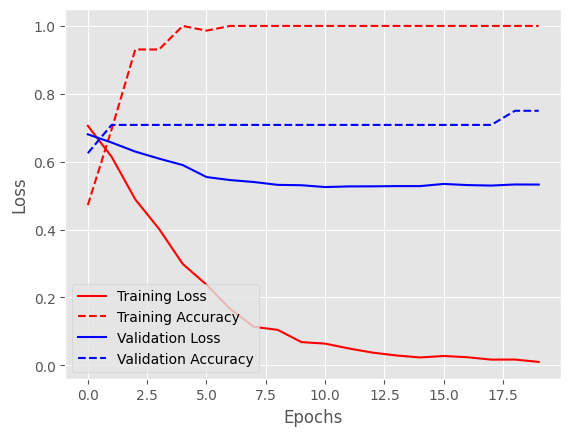

In [46]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

plt.plot(average_loss_history,c='r')
plt.plot(average_acc_history,c="r",linestyle="dashed")
plt.plot(average_val_loss_history,c='b')
plt.plot(average_val_acc_history,c='b',linestyle="dashed")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Training Loss','Training Accuracy','Validation Loss','Validation Accuracy'])
plt.show()

In [47]:
binary_2gram_tf_test = text_vectorization_bi_tfidf(X_test)
binary_2gram_tf_test

<tf.Tensor: shape=(9, 1339), dtype=float32, numpy=
array([[176.78558   ,   3.465736  ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [191.3159    ,   0.6931472 ,   3.0485601 , ...,   0.        ,
          0.        ,   0.        ],
       [191.3159    ,   4.8520303 ,   0.76214004, ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [162.25526   ,   1.3862944 ,   0.76214004, ...,   0.        ,
          0.        ,   0.        ],
       [191.3159    ,   3.465736  ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [176.78558   ,   0.6931472 ,   0.76214004, ...,   0.        ,
          0.        ,   0.        ]], dtype=float32)>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


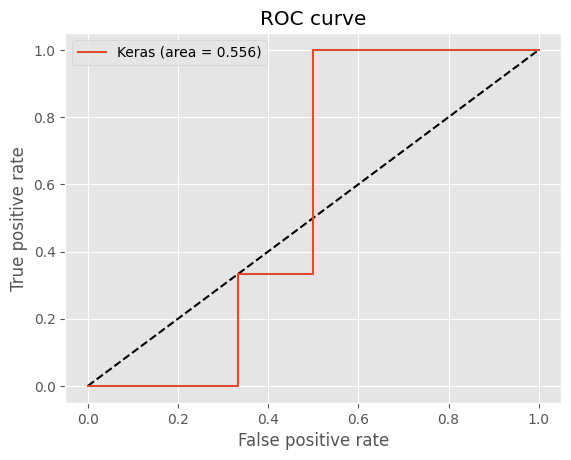

In [48]:
from sklearn.metrics import roc_curve
y_pred_keras = model_bi_tfidf.predict(binary_2gram_tf_test).ravel()
fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test, y_pred_keras)

from sklearn.metrics import auc
auc_keras = auc(fpr_keras, tpr_keras)

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label='Keras (area = {:.3f})'.format(auc_keras))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

In [49]:
 model_bi_tfidf.evaluate(binary_2gram_tf_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3333 - loss: 2.4221


[2.422056198120117, 0.3333333432674408]

# 4- RNN - Bidirectional LSTM

In [50]:
text_vectorization = keras.layers.TextVectorization(
    max_tokens=1000, # maximum tokens are set to 1000 words
    output_mode="int", # This is requesting integer encodings (which means we'll have a sequence of integers)
    ngrams =1 # set ngram = 1 (which means we will consider the seqenuce of the documents)
)

text_vectorization.adapt(df['facts'])

In [51]:
from tensorflow.keras.layers import Lambda

def build_model():
    inputs = keras.layers.Input(shape=(1,), dtype="string")
    processing = text_vectorization(inputs)  # shape: (batch_size, seq_len)

    def one_hot_fn(x):
        return tf.one_hot(x, depth=1500)

    # You can specify output_shape as a function or tuple
    # Assuming sequence_length is fixed (e.g., 100), else None
    output_shape = (None, 1500)  # None for sequence_length (variable)

    one_hot = Lambda(one_hot_fn, output_shape=output_shape)(processing)

    x = layers.Bidirectional(layers.LSTM(16))(one_hot)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=['accuracy'])
    return model

model_lstm = build_model()


In [52]:
import numpy as np
import tensorflow as tf

with tf.device('/cpu:0'):
    k = 4
    num_validation_samples = len(X_train) // k
    num_epochs = 20
    batch_sizes = 250
    all_loss_histories = []
    all_val_loss_histories = []
    all_acc_histories = []
    all_val_acc_histories = []

    for fold in range(k):
        # Extract validation data and targets, convert to list/array
        validation_data = X_train[num_validation_samples * fold : num_validation_samples * (fold + 1)].to_list()
        validation_targets = y_train[num_validation_samples * fold : num_validation_samples * (fold + 1)].to_numpy()

        # Extract training data and targets, concatenate and convert
        training_data = X_train[:num_validation_samples * fold].to_list() + X_train[num_validation_samples * (fold + 1):].to_list()
        training_targets = np.concatenate([
            y_train[:num_validation_samples * fold].to_numpy(),
            y_train[num_validation_samples * (fold + 1):].to_numpy()
        ])

        # Convert string lists to numpy arrays with dtype=object
        training_data_np = np.array(training_data, dtype=object)
        validation_data_np = np.array(validation_data, dtype=object)

        model_lstm = build_model()
        history = model_lstm.fit(training_data_np, training_targets,
                                 validation_data=(validation_data_np, validation_targets),
                                 epochs=num_epochs, batch_size=batch_sizes)

        all_val_loss_histories.append(history.history['val_loss'])
        all_loss_histories.append(history.history['loss'])
        all_val_acc_histories.append(history.history['val_accuracy'])
        all_acc_histories.append(history.history['accuracy'])

    average_loss_history = [np.mean([x[i] for x in all_loss_histories]) for i in range(num_epochs)]
    average_val_loss_history = [np.mean([x[i] for x in all_val_loss_histories]) for i in range(num_epochs)]
    average_acc_history = [np.mean([x[i] for x in all_acc_histories]) for i in range(num_epochs)]
    average_val_acc_history = [np.mean([x[i] for x in all_val_acc_histories]) for i in range(num_epochs)]


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6667 - loss: 0.6865 - val_accuracy: 0.5000 - val_loss: 0.6907
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6667 - loss: 0.6821 - val_accuracy: 0.3333 - val_loss: 0.6914
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6667 - loss: 0.6782 - val_accuracy: 0.3333 - val_loss: 0.6932
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.6667 - loss: 0.6652 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.6111 - loss: 0.6681 - val_accuracy: 0.3333 - val_loss: 0.6940
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.6111 - loss: 0.6693 - val_accuracy: 0.3333 - val_loss: 0.6928
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.6667 - loss: 0.6648 - val_accuracy: 0.3333 - val_loss: 0.6915
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.6667 - loss: 0.6622 - val_accuracy: 0.3333 - val_loss: 0.

In [53]:
np.mean(average_val_acc_history)

0.5666666690260171

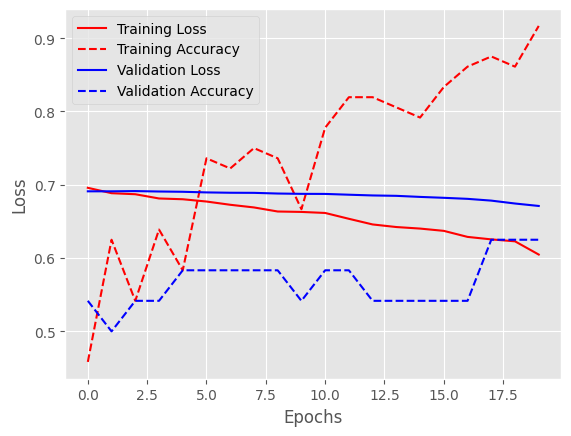

In [54]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

plt.plot(average_loss_history,c='r')
plt.plot(average_acc_history,c="r",linestyle="dashed")
plt.plot(average_val_loss_history,c='b')
plt.plot(average_val_acc_history,c='b',linestyle="dashed")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Training Loss','Training Accuracy','Validation Loss','Validation Accuracy'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step


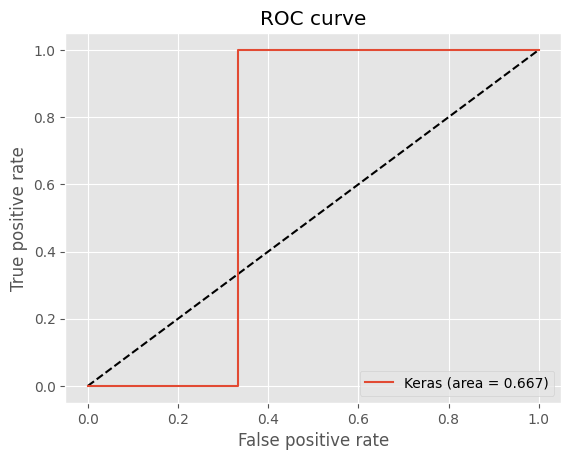

In [55]:
import numpy as np

# Convert X_test to numpy array with dtype object if it's a list or pandas Series of strings
X_test_np = np.array(X_test, dtype=object)

# Now predict
y_pred_keras = model_lstm.predict(X_test_np).ravel()

from sklearn.metrics import roc_curve, auc
fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test, y_pred_keras)
auc_keras = auc(fpr_keras, tpr_keras)

import matplotlib.pyplot as plt
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label=f'Keras (area = {auc_keras:.3f})')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6667 - loss: 0.6919
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


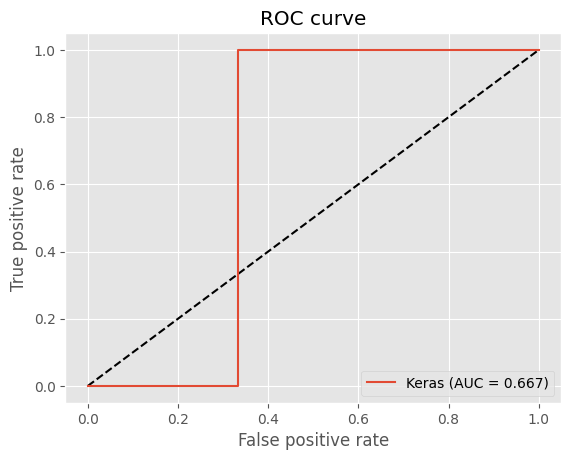

In [56]:
# Use the original list or convert to tf.constant of dtype string
import tensorflow as tf

X_test_tensor = tf.constant(X_test)  # keep it as a tf.Tensor of strings
y_test_tensor = tf.constant(y_test)  # labels as tensor

# Evaluate
model_lstm.evaluate(X_test_tensor, y_test_tensor)

# Predict
y_pred_keras = model_lstm.predict(X_test_tensor).ravel()

# Continue with ROC, etc.
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_keras, tpr_keras, _ = roc_curve(y_test, y_pred_keras)
auc_keras = auc(fpr_keras, tpr_keras)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label=f'Keras (AUC = {auc_keras:.3f})')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()


# 5- LSTM with Text Embeddings:

In [57]:
text_vectorization = keras.layers.TextVectorization(
    max_tokens=1000, # set the maximum tokens at 1000 words
    output_mode="int", # This is requesting integer encodings (which means we'll have a sequence of integers)
    ngrams =1 # set ngram = 1 (which means we will consider the seqenuce of the documents)
)

text_vectorization.adapt(df['facts'])

In [58]:
with tf.device('/cpu:0'):
    def build_model_text_embed():
        inputs = keras.layers.Input(shape=(1,), dtype="string")  # Note the comma here
        processing = text_vectorization(inputs)

        x = layers.Embedding(input_dim=1000, output_dim=8, input_length=500, mask_zero=True)(processing)
        x = layers.Bidirectional(layers.LSTM(12))(x)
        x = keras.layers.Dropout(0.5)(x)
        outputs = layers.Dense(1, activation="sigmoid")(x)

        model = keras.Model(inputs, outputs)
        model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=['accuracy'])
        return model

    model_lstm_text_embed = build_model_text_embed()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [59]:
import tensorflow as tf
import numpy as np

def create_dataset(X, y, batch_size):
    # Convert X (which should be a list of strings or numpy array of objects)
    # and y (numpy array) into TensorFlow datasets.
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

with tf.device('/cpu:0'):
    k = 4
    num_validation_samples = len(X_train) // k
    num_epochs = 20
    batch_sizes = 250
    all_loss_histories = []
    all_val_loss_histories = []
    all_acc_histories = []
    all_val_acc_histories = []

    for fold in range(k):
        # Extract validation data and targets as Series slices
        validation_data_series = X_train[num_validation_samples * fold : num_validation_samples * (fold + 1)]
        validation_targets_series = y_train[num_validation_samples * fold : num_validation_samples * (fold + 1)]

        # Extract training data and targets as Series slices and concatenate
        training_data_series = pd.concat([
            X_train[:num_validation_samples * fold],
            X_train[num_validation_samples * (fold + 1):]
        ])
        training_targets_series = pd.concat([
            y_train[:num_validation_samples * fold],
            y_train[num_validation_samples * (fold + 1):]
        ])

        # Convert pandas Series to lists of strings for the features (X)
        training_data_list = training_data_series.tolist()
        validation_data_list = validation_data_series.tolist()

        # Convert pandas Series to numpy arrays for the labels (y)
        training_targets_np = training_targets_series.to_numpy()
        validation_targets_np = validation_targets_series.to_numpy()

        # Create TensorFlow datasets from the lists and numpy arrays
        train_ds = create_dataset(training_data_list, training_targets_np, batch_sizes)
        val_ds = create_dataset(validation_data_list, validation_targets_np, batch_sizes)

        model_lstm_text_embed = build_model_text_embed()

        history = model_lstm_text_embed.fit(
            train_ds,
            validation_data=val_ds,
            epochs=num_epochs
        )

        all_val_loss_histories.append(history.history['val_loss'])
        all_loss_histories.append(history.history['loss'])
        all_val_acc_histories.append(history.history['val_accuracy'])
        all_acc_histories.append(history.history['accuracy'])

    average_loss_history = [np.mean([x[i] for x in all_loss_histories]) for i in range(num_epochs)]
    average_val_loss_history = [np.mean([x[i] for x in all_val_loss_histories]) for i in range(num_epochs)]
    average_acc_history = [np.mean([x[i] for x in all_acc_histories]) for i in range(num_epochs)]
    average_val_acc_history = [np.mean([x[i] for x in all_val_acc_histories]) for i in range(num_epochs)]

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.5556 - loss: 0.6924 - val_accuracy: 0.3333 - val_loss: 0.6946
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step - accuracy: 0.5556 - loss: 0.6886 - val_accuracy: 0.3333 - val_loss: 0.6959
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6111 - loss: 0.6887 - val_accuracy: 0.3333 - val_loss: 0.6965
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5556 - loss: 0.6873 - val_accuracy: 0.3333 - val_loss: 0.6969
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.5556 - loss: 0.6860 - val_accuracy: 0.3333 - val_loss: 0.6966
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5556 - loss: 0.6847 - val_accuracy: 0.3333 - val_loss: 0.6968
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5556 - loss: 0.6829 - val_accuracy: 0.3333 - val_loss: 0.6968
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6111 - loss: 0.6778 - val_accuracy: 0.3333 - val_loss: 0.697

In [60]:
np.mean(average_val_acc_history)

0.554166666790843

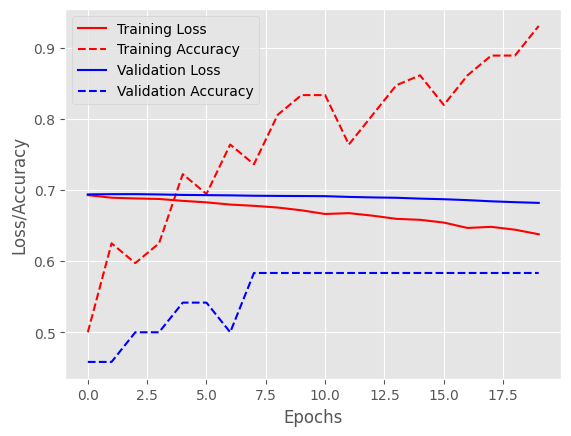

In [61]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

plt.plot(average_loss_history,c='r')
plt.plot(average_acc_history,c="r",linestyle="dashed")
plt.plot(average_val_loss_history,c='b')
plt.plot(average_val_acc_history,c='b',linestyle="dashed")
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.legend(['Training Loss','Training Accuracy','Validation Loss','Validation Accuracy'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step


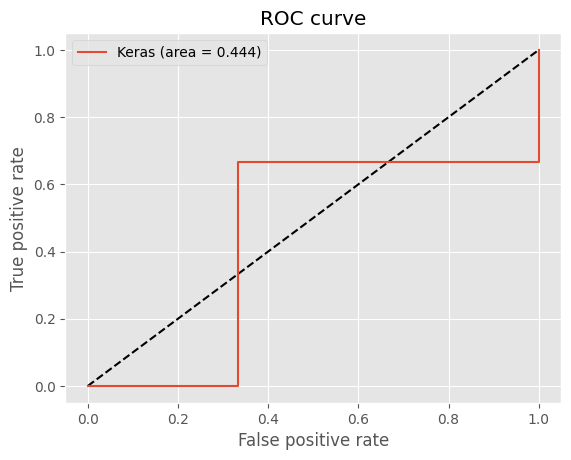

In [62]:
import tensorflow as tf

# Convert X_test (list of strings) into a tf.data.Dataset batch for prediction
batch_size = 256  # or any suitable batch size

test_ds = tf.data.Dataset.from_tensor_slices(X_test).batch(batch_size)

# Get predictions as a single NumPy array
y_pred_keras = model_lstm_text_embed.predict(test_ds).ravel()

# Now compute ROC curve
from sklearn.metrics import roc_curve, auc

fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test, y_pred_keras)
auc_keras = auc(fpr_keras, tpr_keras)

import matplotlib.pyplot as plt

plt.figure()
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label=f'Keras (area = {auc_keras:.3f})')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()


In [63]:
batch_size = 256

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

# Now evaluate
model_lstm_text_embed.evaluate(test_ds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6667 - loss: 0.6897


[0.6896751523017883, 0.6666666865348816]

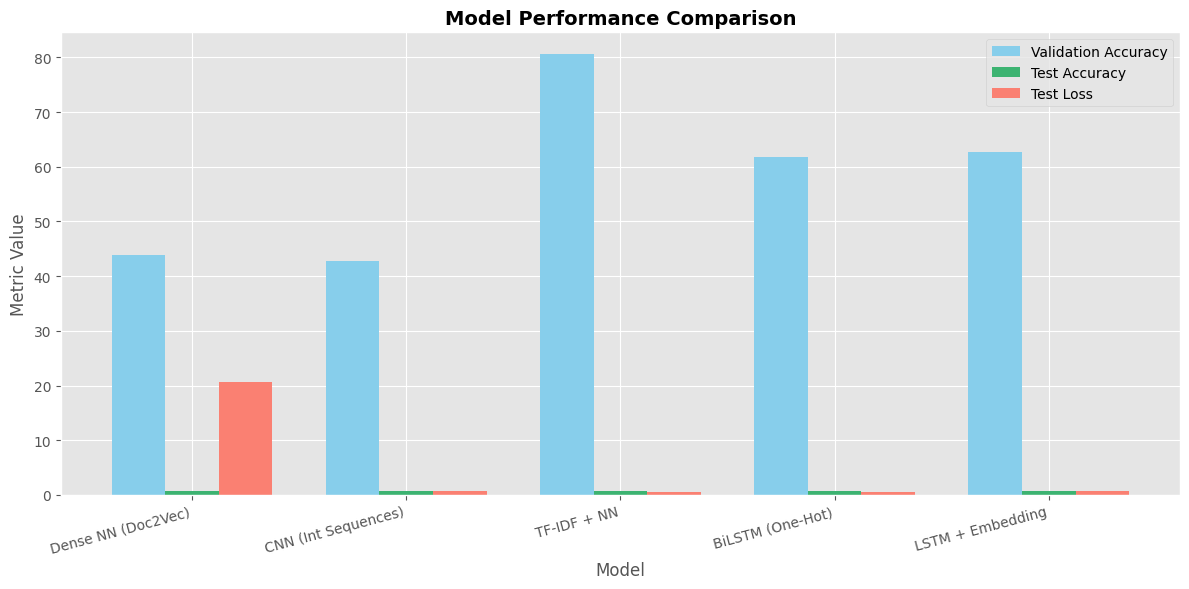

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Model Names
models = [
    "Dense NN (Doc2Vec)",
    "CNN (Int Sequences)",
    "TF-IDF + NN",
    "BiLSTM (One-Hot)",
    "LSTM + Embedding"
]

# Corresponding Metrics (from your table)
val_acc = [43.96, 42.71, 80.56, 61.75, 62.71]      # Validation Accuracy
test_acc = [0.67, 0.66, 0.74, 0.65, 0.67]           # Test Accuracy
test_loss = [20.7, 0.69, 0.58, 0.62, 0.64]          # Test Loss

# Bar positions
x = np.arange(len(models))
bar_width = 0.25

# Create plot
plt.figure(figsize=(12, 6))
plt.bar(x - bar_width, val_acc, width=bar_width, color='skyblue', label='Validation Accuracy')
plt.bar(x, test_acc, width=bar_width, color='mediumseagreen', label='Test Accuracy')
plt.bar(x + bar_width, test_loss, width=bar_width, color='salmon', label='Test Loss')

# Labeling
plt.xlabel('Model', fontsize=12)
plt.ylabel('Metric Value', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, models, rotation=15, ha='right')
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig("model_comparison.png", dpi=300)
plt.show()
